In [1]:
# %% Imports & hot-reload
import os, importlib, numpy as np
from IPython.display import Image, display

import classA_U1FGTN as mod
importlib.reload(mod)
from classA_U1FGTN import classA_U1FGTN

/home/abhuiyan/anaconda3/envs/fermionic_env/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
data1 = np.load('cache/G_history_samples/N21x21_C20_S10_nsh5_DW1_init-default.npz', allow_pickle=True)
data2 = np.load('cache/G_history_samples/N21x21_C20_S10_nsh5_DW1_init-maxmix.npz', allow_pickle=True)

In [3]:
G1 = data1['G_full']
G2 = data2['G_full']
print(G1.shape, G1.dtype)  # probably (S,T) object

same = True
for s in range(G1.shape[0]):
    for t in range(G1.shape[1]):
        if not np.array_equal(G1[s,t], G2[s,t]):
            same = False
            break
print("All trajectories identical:", same)

(10, 20) object
All trajectories identical: False


In [4]:
data3 = np.load('cache/G_history_samples/N21x21_C20_S1_nsh5_DW0_init-default.npz', allow_pickle=True)
G3 = data3['G_full']

In [8]:
print(G3.shape, G3.dtype)  # probably (S,T) object
print(G1[0])

(1, 20, 1764, 1764) complex128
[array([[ 0.10631541+0.j        , -0.01203718+0.03467867j,
         -0.01438424-0.19233247j, ...,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ],
        [-0.01203718-0.03467867j,  0.88476493+0.j        ,
          0.00372009-0.00428805j, ...,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ],
        [-0.01438424+0.19233247j,  0.00372009+0.00428805j,
          0.77925065+0.j        , ...,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ],
        ...,
        [ 0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        , ..., -1.        +0.j        ,
         -0.        +0.j        , -0.        +0.j        ],
        [ 0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        , ..., -0.        +0.j        ,
          1.        +0.j        , -0.        +0.j        ],
        [ 0.        +0.j        ,  0.    

In [10]:
Nx = 21
Ny = 21
Ntot = 4*Nx*Ny
T = 20
S = 10
Ntot = 4*Nx*Ny
G1_prime = np.empty((S, T, Ntot, Ntot), dtype=np.complex128)
G2_prime = np.empty((S, T, Ntot, Ntot), dtype=np.complex128)
for s in range(G1.shape[0]):
    for t in range(G1.shape[1]):
        G1_prime[s,t,:,:] = G1[s][t]
        G2_prime[s,t,:,:] = G2[s][t]     

np.savez_compressed('cache/G_history_samples/N21x21_C20_S10_nsh5_DW1_init-default_prime.npz', G_full=G1_prime) 
np.savez_compressed('cache/G_history_samples/N21x21_C20_S10_nsh5_DW1_init-maxmix_prime.npz', G_full=G2_prime)      

In [ ]:
    def markov_meas_feedback(self, G, Rx, Ry, n_a=1/2):
        '''Perform adaptive measurement plus feedback at site (Rx, Ry).'''
        G = np.asarray(G, dtype=np.complex128)
        Nlayer = self.Ntot // 2
        Il = np.eye(Nlayer, dtype=np.complex128)
        Gtt_2pt = 0.5 * (G[:Nlayer, :Nlayer] + Il)

        # On-the-fly projectors at (Rx, Ry)
        P_Ap = self._proj_from_WF(self.WF_Ap, Rx, Ry)
        P_Bp = self._proj_from_WF(self.WF_Bp, Rx, Ry)
        P_Am = self._proj_from_WF(self.WF_Am, Rx, Ry)
        P_Bm = self._proj_from_WF(self.WF_Bm, Rx, Ry)

        def ancilla_swap(G, P, n_a):
            return (1-P).conj().T @ G (1-P) + (2*n_a-1)*P

        # Upper band A: want UNOCCUPIED
        p_occ = float(np.real(np.trace(Gtt_2pt @ P_Ap))); p_occ = np.clip(p_occ, 0.0, 1.0)
        if np.random.rand() < p_occ:
            G = self.measure_top_layer(G, P_Ap, particle=True)
            G = ancilla_swap(G, P_Ap, n_a)  # swap OUT
        else:
            G = self.measure_top_layer(G, P_Ap, particle=False)

        # Upper band B: want UNOCCUPIED
        p_occ = float(np.real(np.trace(Gtt_2pt @ P_Bp))); p_occ = np.clip(p_occ, 0.0, 1.0)
        if np.random.rand() < p_occ:
            G = self.measure_top_layer(G, P_Bp, particle=True)
            G = ancilla_swap(G, P_Bp, n_a)
        else:
            G = self.measure_top_layer(G, P_Bp, particle=False)

        # Lower band A: want OCCUPIED
        p_occ = float(np.real(np.trace(Gtt_2pt @ P_Am))); p_occ = np.clip(p_occ, 0.0, 1.0)
        if np.random.rand() < p_occ:
            G = self.measure_top_layer(G, P_Am, particle=True)
        else:
            G = self.measure_top_layer(G, P_Am, particle=False)
            G = ancilla_swap(G, P_Am, n_a)  # swap IN

        # Lower band B: want OCCUPIED
        p_occ = float(np.real(np.trace(Gtt_2pt @ P_Bm))); p_occ = np.clip(p_occ, 0.0, 1.0)
        if np.random.rand() < p_occ:
            G = self.measure_top_layer(G, P_Bm, particle=True)
        else:
            G = self.measure_top_layer(G, P_Bm, particle=False)
            G = ancilla_swap(G, P_Bm, n_a)  # swap IN

        return G

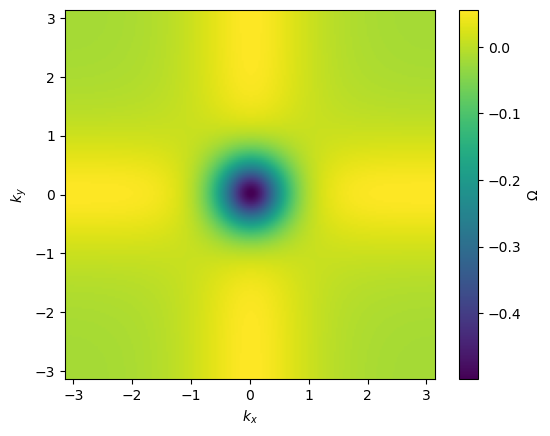

alpha= 3.00  ->  C ≈ +0.000000


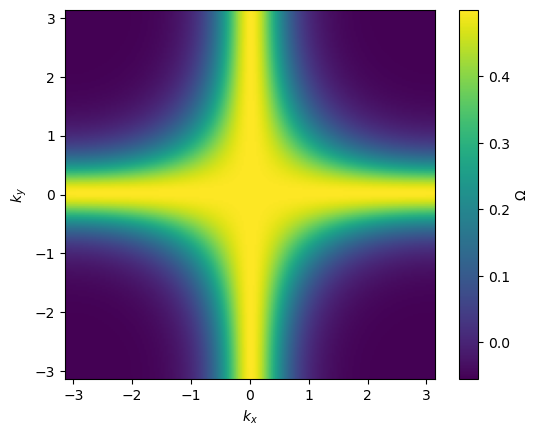

alpha= 1.00  ->  C ≈ +1.000000


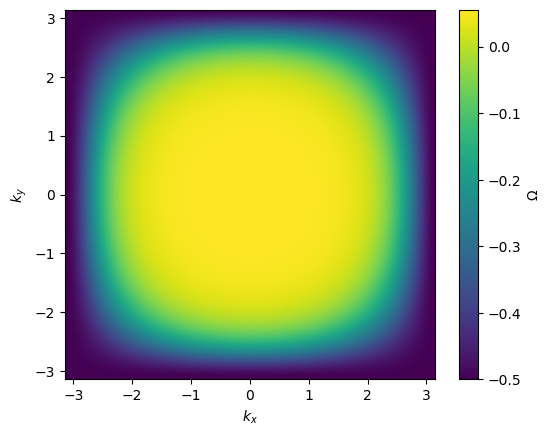

alpha=-1.00  ->  C ≈ -1.000000


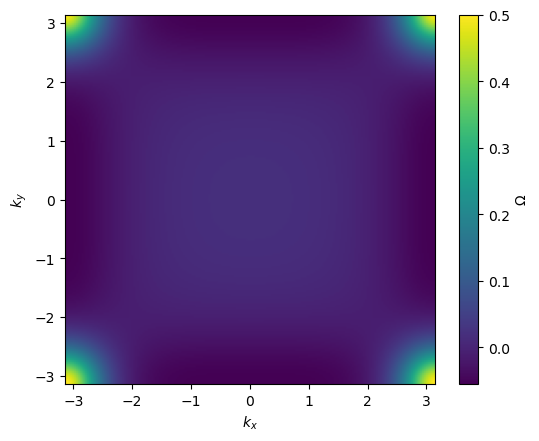

alpha=-3.00  ->  C ≈ -0.000000


In [7]:
import numpy as np

def berry_curvature_QWZ(kx, ky, alpha):
    """
    Berry curvature of the lower band for the Qi–Wu–Zhang (Chern insulator) model:
        n(k) = (sin kx, sin ky, alpha - cos kx - cos ky)
        Omega_-(k) = -1/2 * [ n · (∂_kx n × ∂_ky n) ] / |n|^3

    Parameters
    ----------
    kx, ky : ndarray (same shape)
        Meshgrid arrays for momenta over the Brillouin zone.
    alpha : float
        Model parameter.

    Returns
    -------
    Omega : ndarray
        Berry curvature on the k-grid (lower band).
    """
    sx, sy = np.sin(kx), np.sin(ky)
    cx, cy = np.cos(kx), np.cos(ky)

    nx = sx
    ny = sy
    nz = alpha - cx - cy

    # Derivatives:
    dkx_n = np.stack([cx, np.zeros_like(kx), sx], axis=0)  # (3, Ny, Nx)
    dky_n = np.stack([np.zeros_like(ky), cy, sy], axis=0)  # (3, Ny, Nx)

    # Cross product ∂_kx n × ∂_ky n:
    cross = np.empty_like(dkx_n)
    cross[0] = dkx_n[1]*dky_n[2] - dkx_n[2]*dky_n[1]  # x
    cross[1] = dkx_n[2]*dky_n[0] - dkx_n[0]*dky_n[2]  # y
    cross[2] = dkx_n[0]*dky_n[1] - dkx_n[1]*dky_n[0]  # z

    # Dot with n:
    num = nx*cross[0] + ny*cross[1] + nz*cross[2]  # numerator

    # |n|^2 and |n|^3:
    n2 = nx*nx + ny*ny + nz*nz
    n32 = np.power(n2, 1.5)

    # Avoid divide-by-zero at gap closings by adding a tiny epsilon
    eps = 1e-15
    Omega = -0.5 * num / (n32 + eps)
    return Omega

def integrate_chern(alpha=1.0, N=120, return_grid=False, visualize=True):
    """
    Numerically integrate Berry curvature over the BZ to get the Chern number.

    Parameters
    ----------
    alpha : float
        Model parameter.
    N : int
        Grid size per dimension (use endpoint=False to avoid double counting).
    return_grid : bool
        If True, also return (kx, ky, Omega) for further analysis/plotting.
    visualize : bool
        If True, show a simple imshow() of the curvature.

    Returns
    -------
    C : float
        Numerical Chern number for the lower band.
    (optional) kx, ky, Omega : ndarrays
        If return_grid=True.
    """
    # Brillouin zone: kx, ky in [-pi, pi)
    ks = np.linspace(-np.pi, np.pi, N, endpoint=False)
    kx, ky = np.meshgrid(ks, ks, indexing='xy')

    Omega = berry_curvature_QWZ(kx, ky, alpha)

    # Uniform grid → simple Riemann sum
    dA = (2*np.pi / N) * (2*np.pi / N)
    integral = np.sum(Omega) * dA
    C = integral / (2*np.pi)

    if visualize:
        import matplotlib.pyplot as plt
        plt.imshow(Omega, origin='lower', extent=[-np.pi, np.pi, -np.pi, np.pi])
        #plt.title(rf"Berry curvature $\Omega(k)$, $\alpha={alpha}$")
        plt.xlabel(r"$k_x$")
        plt.ylabel(r"$k_y$")
        plt.colorbar(label=r'$\Omega $')
        plt.show()

    if return_grid:
        return C, kx, ky, Omega
    return C

if __name__ == "__main__":
    for a in [3.0, 1.0, -1.0, -3.0]:
        C = integrate_chern(alpha=a, N=201)
        print(f"alpha={a:5.2f}  ->  C ≈ {C:+.6f}")

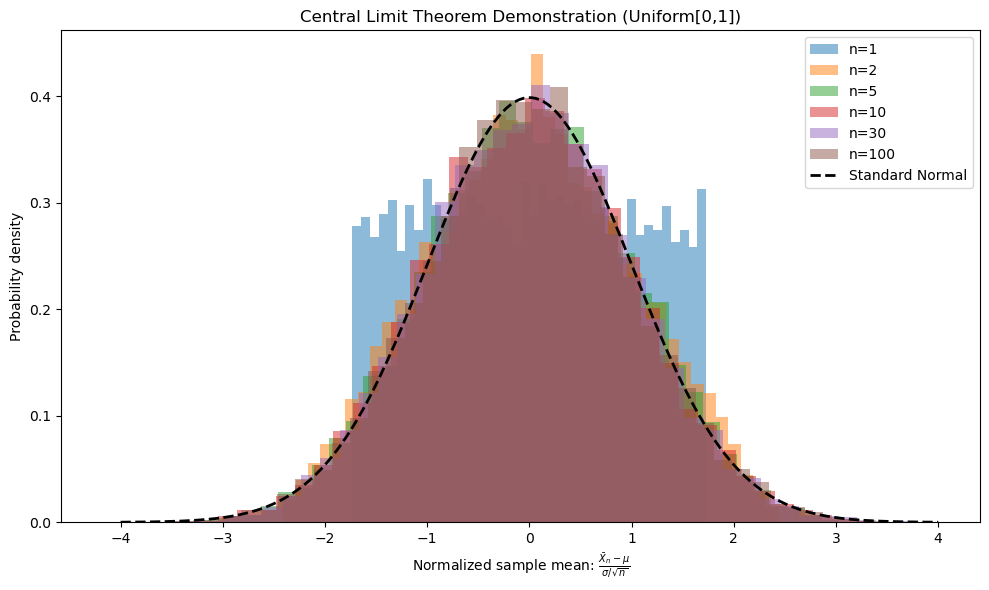

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def demonstrate_clt(num_samples=10000, sample_sizes=[1, 2, 5, 10, 30, 100]):
    """
    Demonstrate the Central Limit Theorem using IID samples from a uniform distribution.
    
    Parameters
    ----------
    num_samples : int
        Number of independent averages to compute for each sample size.
    sample_sizes : list of int
        Different sample sizes to test (n in the CLT).
    """

    # Uniform distribution parameters
    a, b = 0, 1  # uniform on [0,1]
    mu_theoretical = (a + b) / 2       # mean of uniform
    sigma_theoretical = (b - a) / np.sqrt(12)  # std of uniform

    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 1, 50)

    for n in sample_sizes:
        # Draw IID uniform samples and compute their means
        samples = np.random.uniform(a, b, size=(num_samples, n))
        sample_means = samples.mean(axis=1)

        # Normalize the sample means to have mean 0 and unit variance
        normalized_means = (sample_means - mu_theoretical) / (sigma_theoretical / np.sqrt(n))

        # Plot the normalized histogram
        plt.hist(normalized_means, bins=40, density=True, alpha=0.5, label=f"n={n}")

    # Overlay standard normal curve for reference
    x = np.linspace(-4, 4, 200)
    plt.plot(x, 1/np.sqrt(2*np.pi) * np.exp(-x**2/2), 'k--', lw=2, label="Standard Normal")

    plt.title("Central Limit Theorem Demonstration (Uniform[0,1])")
    plt.xlabel(r"Normalized sample mean: $\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}}$")
    plt.ylabel("Probability density")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    demonstrate_clt()

/home/abhuiyan/anaconda3/envs/fermionic_env/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/home/abhuiyan/anaconda3/envs/fermionic_env/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


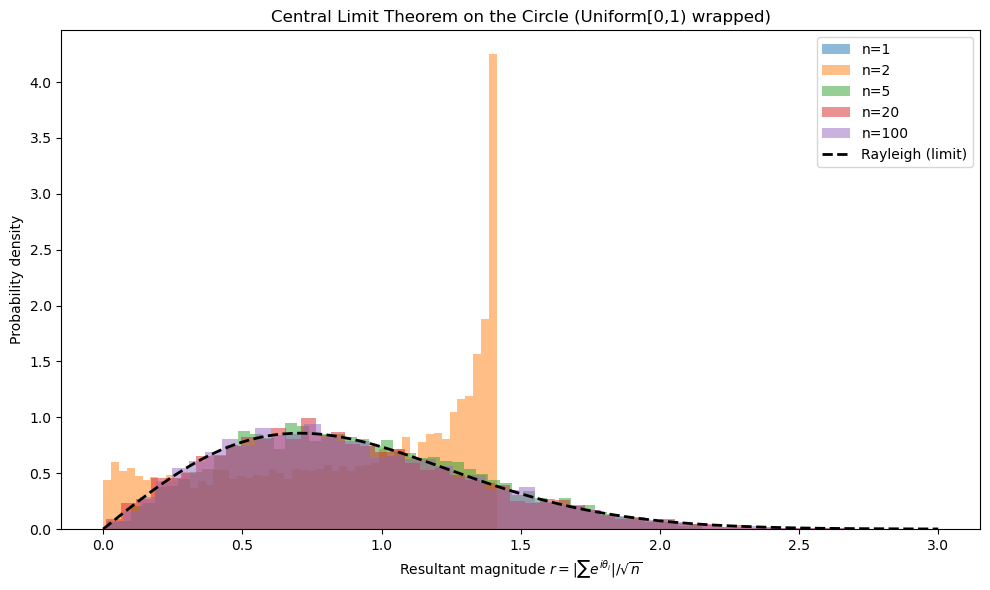

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def clt_on_circle(num_samples=5000, n_values=[1, 2, 5, 20, 100]):
    """
    Demonstrate the 'circular' Central Limit Theorem:
    summing random angles θ_i ~ Uniform(0, 2π).
    The resultant vector sum tends to a 2D Gaussian.
    """
    plt.figure(figsize=(10, 6))

    for n in n_values:
        # Draw uniform angles θ_i in [0, 2π)
        theta = 2 * np.pi * np.random.rand(num_samples, n)

        # Convert to unit vectors and sum
        x = np.cos(theta).sum(axis=1)
        y = np.sin(theta).sum(axis=1)

        # Normalize by √n
        x /= np.sqrt(n)
        y /= np.sqrt(n)

        # Compute radial distribution
        r = np.sqrt(x**2 + y**2)

        # Plot histogram of x or r
        plt.hist(r, bins=50, density=True, alpha=0.5, label=f"n={n}")

    # Rayleigh distribution for comparison
    from scipy.stats import rayleigh
    r_vals = np.linspace(0, 3, 200)
    plt.plot(r_vals, rayleigh(scale=1/np.sqrt(2)).pdf(r_vals), 'k--', lw=2, label="Rayleigh (limit)")

    plt.title("Central Limit Theorem on the Circle (Uniform[0,1) wrapped)")
    plt.xlabel("Resultant magnitude $r = |\\sum e^{i\\theta_i}|/\\sqrt{n}$")
    plt.ylabel("Probability density")
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    clt_on_circle()

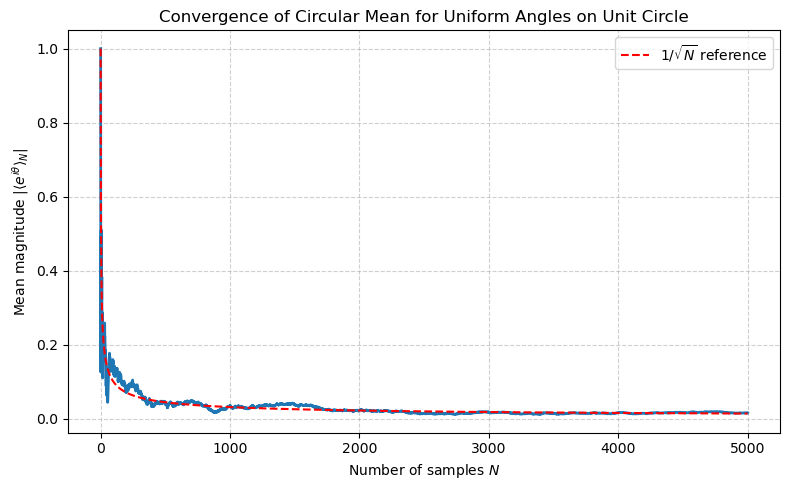

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def circular_average_demo(N_max=1000):
    """
    Sample random angles θ ~ Uniform(0, 2π)
    and compute the running average of e^{iθ}.
    Plot |⟨e^{iθ}⟩_N| versus N.
    """
    # Generate N_max random angles
    theta = 2 * np.pi * np.random.rand(N_max)

    # Convert to unit complex numbers e^{iθ}
    z = np.exp(1j * theta)

    # Compute running (cumulative) average
    running_avg = np.cumsum(z) / np.arange(1, N_max + 1)

    # Magnitude of the average (should decay ~ 1/sqrt(N))
    avg_magnitude = np.abs(running_avg)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, N_max + 1), avg_magnitude, lw=2)
    plt.plot(np.arange(1, N_max + 1), 1 / np.sqrt(np.arange(1, N_max + 1)),
             'r--', label=r"$1/\sqrt{N}$ reference")

    plt.xlabel("Number of samples $N$")
    plt.ylabel(r"Mean magnitude $|\langle e^{i\theta}\rangle_N|$")
    plt.title("Convergence of Circular Mean for Uniform Angles on Unit Circle")
    plt.legend()
    plt.grid(True, ls='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    circular_average_demo(N_max=5000)

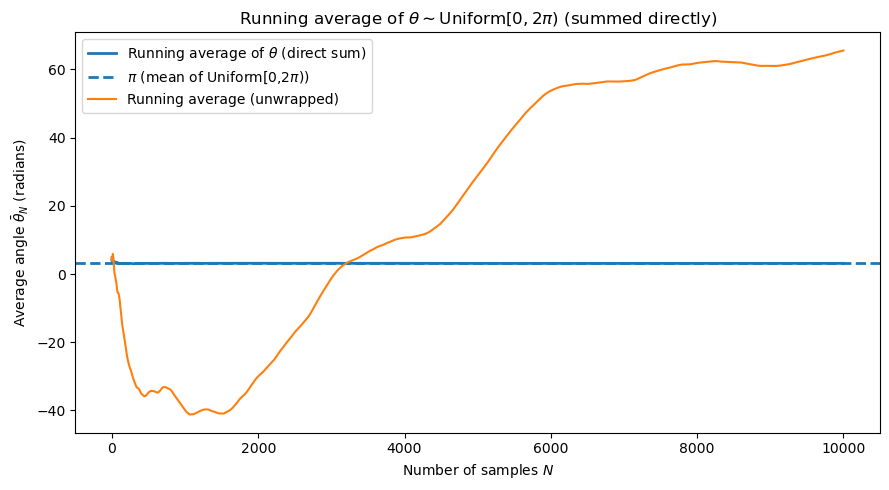

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def average_theta_linear(N_max=5000, seed=None, show_unwrapped=False):
    """
    Sample theta ~ Uniform(0, 2π) and compute the running average of theta directly.
    Optionally also compute an 'unwrapped' running average to illustrate continuity handling.
    """
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0.0, 2*np.pi, size=N_max)  # θ lives on S^1, parameterized by [0, 2π)

    # Running average by summing θ directly (as requested)
    running_avg = np.cumsum(theta) / np.arange(1, N_max + 1)

    # Optional: phase-unwrapped running average (for comparison only; not required)
    if show_unwrapped:
        # Unwrap by removing 2π jumps to keep continuity before averaging
        theta_unwrapped = np.unwrap(theta)  # works on radians assuming small step discontinuities
        running_avg_unwrapped = np.cumsum(theta_unwrapped) / np.arange(1, N_max + 1)
    else:
        running_avg_unwrapped = None

    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(np.arange(1, N_max + 1), running_avg, lw=2, label=r"Running average of $\theta$ (direct sum)")
    plt.axhline(np.pi, linestyle='--', linewidth=2, label=r"$\pi$ (mean of Uniform[0,2$\pi$))")

    if running_avg_unwrapped is not None:
        plt.plot(np.arange(1, N_max + 1), running_avg_unwrapped, linewidth=1.5, label="Running average (unwrapped)")

    plt.xlabel("Number of samples $N$")
    plt.ylabel(r"Average angle $\bar{\theta}_N$ (radians)")
    plt.title(r"Running average of $\theta \sim \mathrm{Uniform}[0,2\pi)$ (summed directly)")
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    average_theta_linear(N_max=10000, seed=42, show_unwrapped=True)

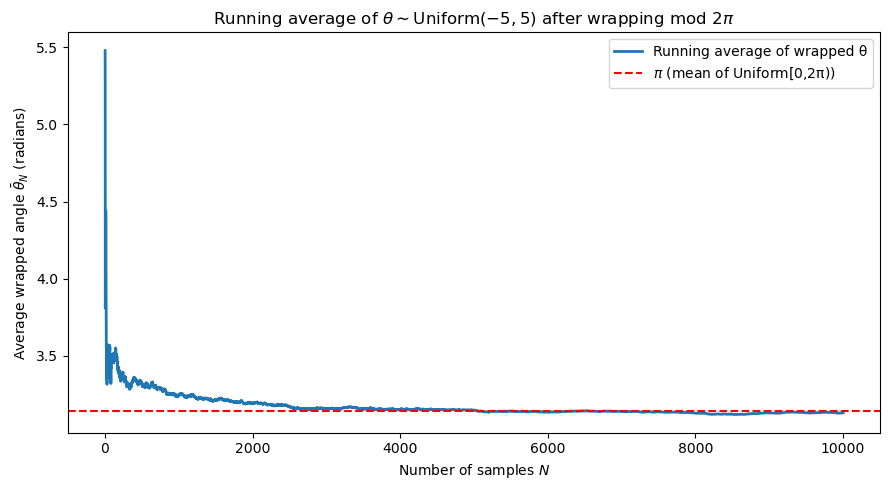

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def average_wrapped_theta(N_max=5000, seed=None):
    """
    Sample θ ~ Uniform(-5, 5), wrap each θ onto the unit circle via mod(2π),
    then compute and plot the running average of the wrapped θ values.
    """
    rng = np.random.default_rng(seed)
    # Step 1: sample from uniform(-5, 5)
    theta_raw = rng.uniform(-10, 10, size=N_max)
    
    # Step 2: wrap onto [0, 2π)
    theta_wrapped = np.mod(theta_raw, 2 * np.pi)
    
    # Step 3: running average of the wrapped θ
    running_avg = np.cumsum(theta_wrapped) / np.arange(1, N_max + 1)
    
    # Step 4: plot results
    plt.figure(figsize=(9, 5))
    plt.plot(np.arange(1, N_max + 1), running_avg, lw=2, label="Running average of wrapped θ")
    plt.axhline(np.pi, color='r', linestyle='--', label=r"$\pi$ (mean of Uniform[0,2π))")
    
    plt.xlabel("Number of samples $N$")
    plt.ylabel(r"Average wrapped angle $\bar{\theta}_N$ (radians)")
    plt.title(r"Running average of $\theta \sim \mathrm{Uniform}(-5,5)$ after wrapping mod $2\pi$")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    average_wrapped_theta(N_max=10000, seed=42)

DWs at x=(4, 11)
------------------------- classA_U1FGTN Initialized -------------------------


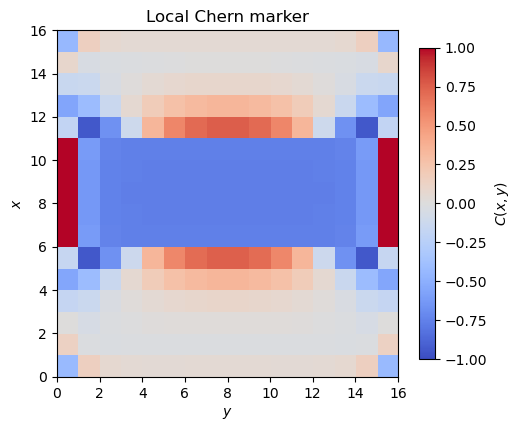

In [6]:
from classA_U1FGTN import classA_U1FGTN
import matplotlib.pyplot as plt

# --- build a state (use whatever G you already have; here I take the DW CI ground state) ---
Nx, Ny = 16, 16
model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=True)
G_snapshot = model.G_CI_domain_wall()

# --- local Chern marker on the top layer ---
chern_map = model.local_chern_marker_flat(G_snapshot)  # shape (Nx, Ny)

# --- plot (mirrors chern_marker_dynamics’ frame generation) ---
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(
    chern_map,
    origin="lower",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    extent=[0, Nx, 0, Ny],
    aspect="auto",
)
ax.set_xlabel("$y$")
ax.set_ylabel("$x$")
ax.set_title("Local Chern marker")
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("$C(x,y)$")
plt.show()
